In [ ]:

import pandas as pd
import numpy as np

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV
)

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

from sklearn.pipeline import Pipeline

from imblearn.pipeline import Pipeline as ImbPipeline

from imblearn.over_sampling import SMOTE

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    cohen_kappa_score,
    matthews_corrcoef
)

from imblearn.metrics import geometric_mean_score

# Models

from sklearn.linear_model import LogisticRegression

from sklearn.neighbors import KNeighborsClassifier

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

from sklearn.neural_network import MLPClassifier

from xgboost import XGBClassifier

import shap
import lime
import lime.lime_tabular

from scipy.stats import randint
from scipy.stats import uniform

import warnings
warnings.filterwarnings("ignore")

In [ ]:
# LOAD DATASET AND DEFINE DATASET
df = pd.read_csv("INCART 2-lead Arrhythmia Database.csv")
print(df.shape)
df.head()

(150179, 34)


,record,type,0_pre-RR,0_post-RR,0_pPeak,0_tPeak,0_rPeak,0_sPeak,0_qPeak,0_qrs_interval,...,1_qPeak,1_qrs_interval,1_pq_interval,1_qt_interval,1_st_interval,1_qrs_morph0,1_qrs_morph1,1_qrs_morph2,1_qrs_morph3,1_qrs_morph4
0,I01,N,163,165,0.069610,-0.083281,0.614133,-0.392761,0.047159,15.0,...,-0.023370,14.0,3.0,23.0,6.0,-0.023370,-0.011650,0.082608,0.101373,-0.183387
1,I01,N,165,166,-0.097030,0.597254,-0.078704,-0.078704,-0.137781,3.0,...,0.081637,15.0,5.0,27.0,7.0,0.081637,0.102992,0.191225,0.217544,-0.068248
2,I01,N,166,102,0.109399,0.680528,-0.010649,-0.010649,-0.720620,6.0,...,-0.148539,33.0,13.0,52.0,6.0,-0.148539,-0.060620,0.081080,0.204400,0.335172
3,I01,VEB,102,231,0.176376,0.256431,-0.101098,-0.707525,-0.101098,4.0,...,0.046898,21.0,9.0,34.0,4.0,0.046898,0.083728,0.279512,0.526785,0.450969
4,I01,N,231,165,0.585577,0.607461,-0.083499,-0.083499,-0.167858,3.0,...,-0.112552,32.0,5.0,43.0,6.0,-0.112552,0.012989,0.091491,0.134004,0.265232


In [ ]:
#DATA PREPROCESSING
# Remove duplicate rows
df = df.drop_duplicates()

# Missing values
df.isnull().sum()

# Remove identifier column
df.drop(columns=['record'], inplace=True)

# Separate X and y
X = df.drop("type", axis=1)
y = df["type"]

# Encode target labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

In [ ]:
# STEP 4 : TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)

print(X_train.shape)
print(X_test.shape)

(120143, 32)
(30036, 32)


In [ ]:
models = {

'Logistic Regression':

LogisticRegression(
    max_iter=300,
    random_state=42
),

'KNN':

KNeighborsClassifier(),

'Decision Tree':

DecisionTreeClassifier(
    random_state=42
),

'Random Forest':

RandomForestClassifier(
    n_estimators=50,
    n_jobs=-1,
    random_state=42
),

'SVM':
CalibratedClassifierCV(
    LinearSVC(
        random_state=42,
        max_iter=2000,
        dual=False
    ),
    cv=3
),

'MLP':
MLPClassifier(
    max_iter=200,
    random_state=42
),

'XGBoost':
XGBClassifier(
    n_estimators=50,
    max_depth=3,
    tree_method='hist',
    n_jobs=-1,
    eval_metric='mlogloss',
    random_state=42
)

}

In [ ]:
params = {

'Logistic Regression':{

'model__C':[0.1,1]

},

'KNN':{

'model__n_neighbors':[3,5]
},

'Decision Tree':{

'model__max_depth':[5,10]

},

'Random Forest':{

'model__n_estimators':[30,50],

'model__max_depth':[5,10]

},

'SVM':{

'model__estimator__C':[0.5,1]

},

'MLP':{

'model__hidden_layer_sizes':[(50,)],

'model__learning_rate_init':[0.001]

},

'XGBoost':{

'model__max_depth':[3,5],

'model__learning_rate':[0.05,0.1]

}

}

In [ ]:
# STEP 7 : STRATIFIED K FOLD
skf = StratifiedKFold(
n_splits=3,
shuffle=True,
random_state=42
)

In [ ]:
fold_results=[]
summary_results=[]
best_models={}

for model_name,model in models.items():
    print("\n"+"="*60)
    print(f"MODEL : {model_name}")

    pipeline=ImbPipeline([
        ('scaler',StandardScaler()),
        ('smote',SMOTE(random_state=42,k_neighbors=1)),
        ('model',model)
    ])

    search=RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=
        params[model_name],
        n_iter=2,
        cv=skf,
        scoring='f1_weighted',
        n_jobs=-1,
        random_state=42
    )

    search.fit(
    X_train,
    y_train
    )

    best_model=search.best_estimator_

    best_models[model_name]=best_model

    model_fold=[]

    fold_no=1

    for train_idx,val_idx in skf.split(
    X_train,
    y_train
    ):
        X_tr=X_train.iloc[train_idx]

        X_val=X_train.iloc[val_idx]

        y_tr=y_train[train_idx]

        y_val=y_train[val_idx]

        best_model.fit(X_tr,y_tr)

        pred=best_model.predict(X_val)

        accuracy=accuracy_score(y_val,pred)
        precision=precision_score(y_val,pred,average='weighted')
        recall=recall_score(y_val,pred,average='weighted')
        f1=f1_score(y_val,pred,average='weighted')
        kappa=cohen_kappa_score(y_val,pred)
        mcc=matthews_corrcoef(y_val,pred)
        gmean=geometric_mean_score(y_val,pred,average='weighted')
        try:
            prob=best_model.predict_proba(X_val)
            roc=roc_auc_score(y_val,prob,multi_class='ovr',average='weighted')
        except:
            roc=np.nan

        fold_data={

'Model':model_name,
'Fold':fold_no,
'Accuracy':round(float(accuracy),4),
'Precision':round(float(precision),4),
'Recall':round(float(recall),4),
'F1':round(float(f1),4),
'ROC':round(float(roc),4),
'Kappa':round(float(kappa),4),
'MCC':round(float(mcc),4),
'GMean':round(float(gmean),4)

}

        fold_results.append(fold_data)
        model_fold.append(fold_data)

        print(
        f"Fold {fold_no}"
        )

        print(fold_data)
        fold_no+=1
    mean_result={

'Model':model_name,

'Accuracy':round(float(np.mean(
[x['Accuracy'] for x in model_fold]
)),4),

'Precision':round(float(np.mean(
[x['Precision'] for x in model_fold]
)),4),

'Recall':round(float(np.mean(
[x['Recall'] for x in model_fold]
)),4),

'F1':round(float(np.mean(
[x['F1'] for x in model_fold]
)),4),

'ROC':round(float(np.nanmean(
[x['ROC'] for x in model_fold]
)),4),

'Kappa':round(float(np.mean(
[x['Kappa'] for x in model_fold]
)),4),

'MCC':round(float(np.mean(
[x['MCC'] for x in model_fold]
)),4),

'GMean':round(float(np.mean(
[x['GMean'] for x in model_fold]
)),4),

'Best_Params':
str(search.best_params_)

}
    summary_results.append(mean_result)

    print("\nMEAN RESULT")

    print(mean_result)

fold_df=pd.DataFrame(fold_results)

summary_df=pd.DataFrame(summary_results)

fold_df.to_excel(
"AllFoldResults.xlsx",
index=False
)

summary_df.to_excel(
"AllModelsResults.xlsx",
index=False
)

print("\nFINAL SUMMARY")

print(summary_df)


MODEL : Logistic Regression
Fold 1
{'Model': 'Logistic Regression', 'Fold': 1, 'Accuracy': 0.8664, 'Precision': 0.9831, 'Recall': 0.8664, 'F1': 0.9186, 'ROC': 0.9921, 'Kappa': 0.5997, 'MCC': 0.6553, 'GMean': 0.9237}
Fold 2
{'Model': 'Logistic Regression', 'Fold': 2, 'Accuracy': 0.8745, 'Precision': 0.9817, 'Recall': 0.8745, 'F1': 0.9228, 'ROC': 0.9902, 'Kappa': 0.6146, 'MCC': 0.6652, 'GMean': 0.9264}
Fold 3
{'Model': 'Logistic Regression', 'Fold': 3, 'Accuracy': 0.8812, 'Precision': 0.9813, 'Recall': 0.8812, 'F1': 0.9258, 'ROC': 0.9926, 'Kappa': 0.6301, 'MCC': 0.6775, 'GMean': 0.9329}

MEAN RESULT
{'Model': 'Logistic Regression', 'Accuracy': 0.874, 'Precision': 0.982, 'Recall': 0.874, 'F1': 0.9224, 'ROC': 0.9916, 'Kappa': 0.6148, 'MCC': 0.666, 'GMean': 0.9277, 'Best_Params': "{'model__C': 0.1}"}

MODEL : KNN
Fold 1
{'Model': 'KNN', 'Fold': 1, 'Accuracy': 0.9947, 'Precision': 0.9947, 'Recall': 0.9947, 'F1': 0.9947, 'ROC': 0.9935, 'Kappa': 0.9765, 'MCC': 0.9765, 'GMean': 0.9918}
Fold 2


In [ ]:
#TOP 2 MODELS
summary_df=summary_df.sort_values(
'F1',
ascending=False
)

top2=summary_df.head(2)
print(top2)

#FINAL MODEL EVALUATION
for model_name in top2['Model']:
    print("\n")
    print(model_name)
    model=best_models[model_name]
    model.fit(
        X_train,
        y_train
    )
    X_test = X_test.fillna(X_train.median())
    pred=model.predict(X_test)
    print("F1:",f1_score(y_test,pred,average='weighted'))

  Model  Accuracy  Precision  Recall      F1     ROC   Kappa     MCC   GMean  \
1   KNN    0.9945     0.9947  0.9945  0.9946  0.9934  0.9756  0.9757  0.9917   
5   MLP    0.9940     0.9944  0.9940  0.9941  0.9981  0.9734  0.9735  0.9919   

                                         Best_Params  
1                          {'model__n_neighbors': 3}  
5  {'model__learning_rate_init': 0.001, 'model__h...  


KNN
F1: 0.9947609352594952


MLP
F1: 0.9927459841417595


In [ ]:
# =========================
# LIME EXPLAINABILITY
# =========================

lime_explainer = lime.lime_tabular.LimeTabularExplainer(

    training_data=np.array(X_train),

    feature_names=X_train.columns,

    class_names=label_encoder.classes_,

    mode='classification'

)

instance = X_test.iloc[0]

# LIME FOR TOP MODEL 1

top_model1 = best_models[
top2.iloc[0]['Model']
]

lime_exp_model1 = lime_explainer.explain_instance(

    data_row=instance,

    predict_fn=
    top_model1.predict_proba

)

print(
"MODEL:",
top2.iloc[0]['Model']
)

lime_exp_model1.show_in_notebook(
show_table=True
)

# LIME FOR TOP MODEL 2

top_model2 = best_models[
top2.iloc[1]['Model']
]

lime_exp_model2 = lime_explainer.explain_instance(

    data_row=instance,

    predict_fn=
    top_model2.predict_proba

)

print(
"MODEL:",
top2.iloc[1]['Model']
)

lime_exp_model2.show_in_notebook(
show_table=True
)

Output hidden; open in https://colab.research.google.com to view.

MODEL: KNN


  0%|          | 0/10 [00:00<?, ?it/s]

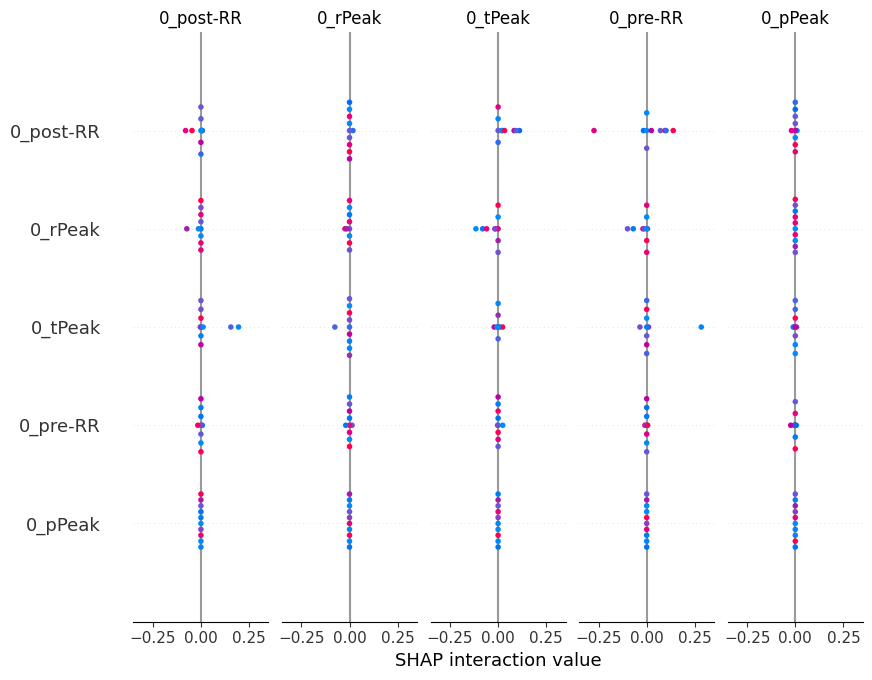

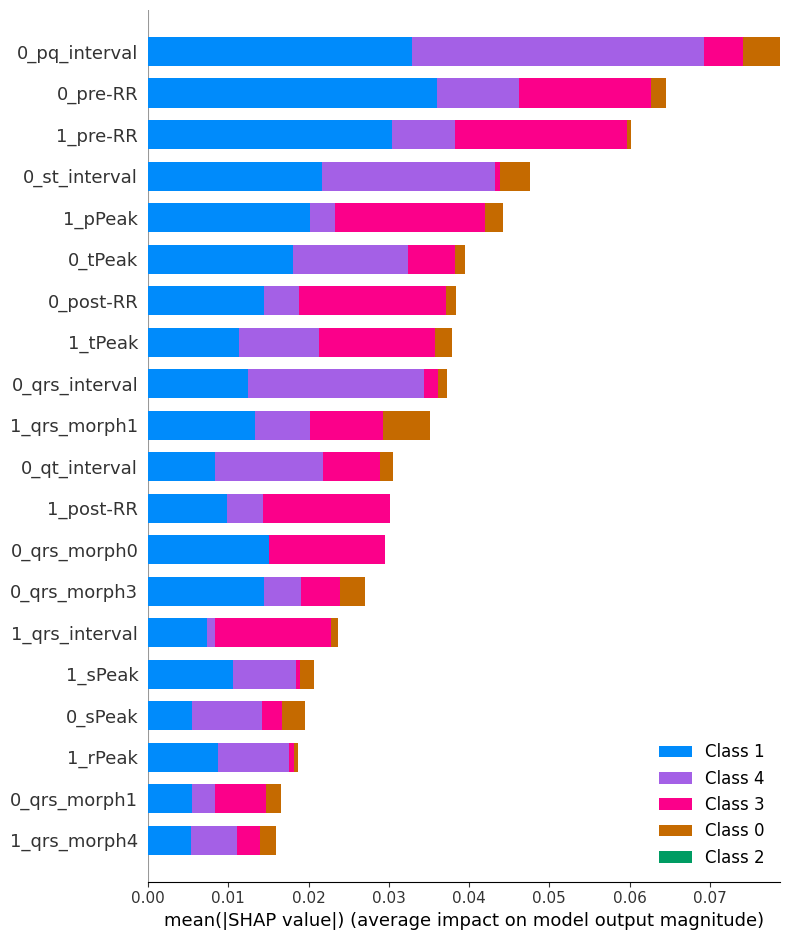

MODEL: MLP


  0%|          | 0/10 [00:00<?, ?it/s]

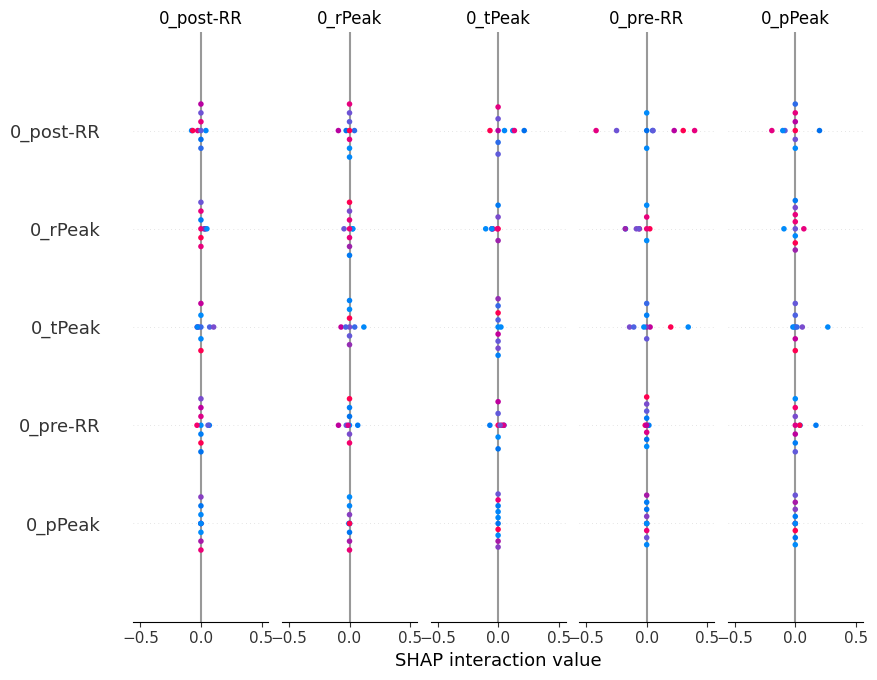

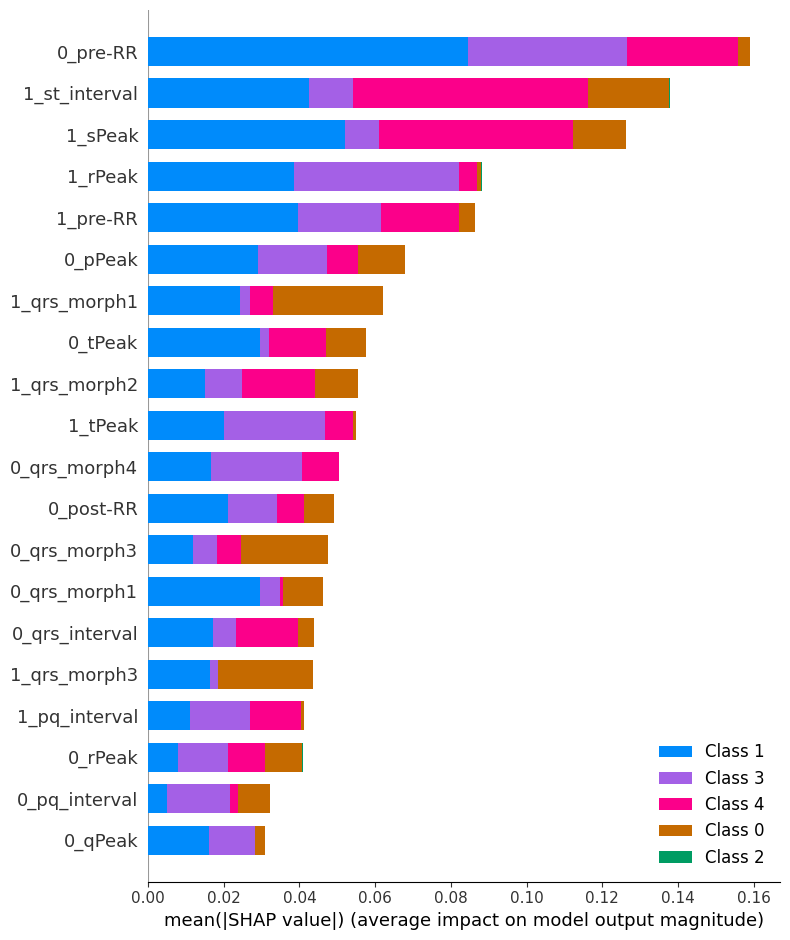

In [ ]:
# ==========================
# FAST SHAP (PIPELINE FIX)
# ==========================

import shap

background = X_train.sample(
    30,
    random_state=42
)

X_explain = X_test.sample(
    10,
    random_state=42
)

# TOP MODEL 1

model1_name = top2.iloc[0]['Model']

model1 = best_models[
    model1_name
]

print(
"MODEL:",
model1_name
)

predict_fn1 = lambda x: model1.predict_proba(
    pd.DataFrame(
        x,
        columns=X_train.columns
    )
)

explainer1 = shap.KernelExplainer(

    predict_fn1,

    background.values

)

shap_values1 = explainer1.shap_values(

    X_explain.values,

    nsamples=50

)

shap.summary_plot(

    shap_values1,

    X_explain

)

shap.summary_plot(

    shap_values1,

    X_explain,

    plot_type='bar'

)

# TOP MODEL 2

model2_name = top2.iloc[1]['Model']

model2 = best_models[
    model2_name
]

print(
"MODEL:",
model2_name
)

predict_fn2 = lambda x: model2.predict_proba(
    pd.DataFrame(
        x,
        columns=X_train.columns
    )
)

explainer2 = shap.KernelExplainer(

    predict_fn2,

    background.values

)

shap_values2 = explainer2.shap_values(

    X_explain.values,

    nsamples=50

)

shap.summary_plot(

    shap_values2,

    X_explain

)

shap.summary_plot(

    shap_values2,

    X_explain,

    plot_type='bar'

)